# Load data

In [ ]:
import pickle
def load_pickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f)
# Load and prepare data
train_data = load_pickle("../data/train.pickel")
test_data = load_pickle("../data/test.pickle")


# Multi-Label Classification Workflow Overview

This cell implements a complete workflow for a multi-label classification task using both sensor and tabular data. The main steps are:

1. **Library Imports**  
    Imports essential libraries for data manipulation (`pandas`, `numpy`), machine learning (`scikit-learn`, `xgboost`), visualization (`matplotlib`), and utility functions.

2. **Reproducibility**  
    Sets a random seed to ensure consistent results across runs.

3. **Utility Functions**  
    Defines helper functions for:
    - Loading pickled data files
    - Converting integer labels to multi-label tuples
    - Extracting advanced statistical and FFT-based features from sensor data
    - Oversampling to balance multi-label classes

4. **Data Loading and Preprocessing**  
    - Loads training and test datasets
    - Removes unnecessary columns
    - Imputes missing values using KNN imputation
    - Scales tabular and sensor features appropriately
 The model used in this workflow is an ensemble of Classifier Chains, each with an XGBoost classifier as the base estimator.
 
 - **ClassifierChain**: This is a multi-label classification strategy where each label is predicted in a chain, and the prediction of previous labels is used as additional input for subsequent labels. This allows the model to capture label dependencies.
- **Ensemble**: Multiple classifier chains (with different random label orders) are trained to increase robustness and reduce variance. Their predicted probabilities are averaged for the final prediction.
- **XGBClassifier**: This is the base model in each chain. XGBoost is a powerful gradient boosting algorithm known for its performance and flexibility. Here, it is configured with `use_label_encoder=False`, `eval_metric='logloss'`, and `scale_pos_weight=5` to handle class imbalance.
 


5. **Feature Engineering**  
    - Extracts advanced features from sensor data (mean, std, skewness, kurtosis, FFT features)
    - Combines tabular and sensor features into a single input matrix

6. **Label Transformation**  
    Converts class labels into a multi-label (binary) format suitable for multi-output classification.

7. **Data Balancing**  
    Applies oversampling to ensure each label combination is sufficiently represented in the training set.

8. **Model Training**  
    - Trains an ensemble of Classifier Chains using XGBoost as the base classifier
    - Each chain uses a different random order of labels

9. **Prediction and Thresholding**  
    - Aggregates predictions from all classifier chains
    - Applies custom probability thresholds for each label to determine final predictions

10. **Evaluation**  
     - Computes and prints classification metrics (classification report, subset accuracy, hamming accuracy, per-label accuracy)
     - Plots normalized confusion matrices for each label to visualize performance



C:\Users\anuhe\AppData\Local\Temp\ipykernel_17352\703816791.py:24: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  return pickle.load(f)
C:\Users\anuhe\AppData\Local\Temp\ipykernel_17352\703816791.py:24: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access funct


Classification Report:

              precision    recall  f1-score   support

  front_left       0.16      0.61      0.25       103
 front_right       0.21      0.69      0.33        96
   rear_left       0.27      0.58      0.36       104
  rear_right       0.15      0.46      0.23       105

   micro avg       0.19      0.58      0.29       408
   macro avg       0.20      0.58      0.29       408
weighted avg       0.20      0.58      0.29       408
 samples avg       0.17      0.24      0.19       408


Subset Accuracy: 0.2607
Hamming Accuracy: 0.7055

Per-label Accuracy:
front_left: 0.6274
front_right: 0.7273
rear_left: 0.7902
rear_right: 0.6773


C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\anuhe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classificati

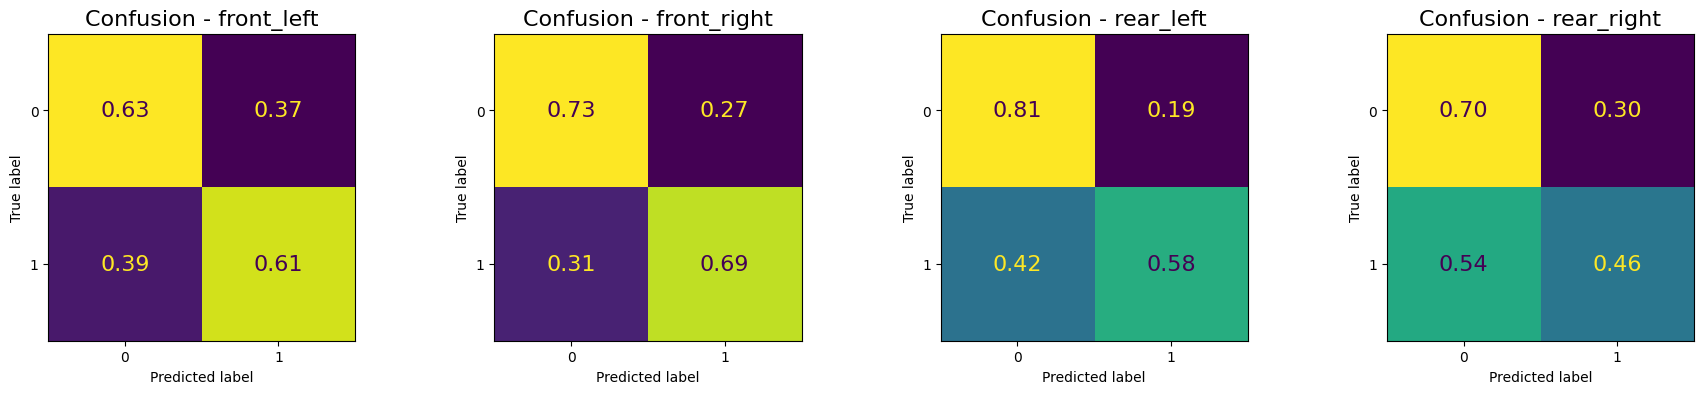

In [ ]:
import torch
import pickle
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from typing import Tuple
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import classification_report, accuracy_score, hamming_loss, multilabel_confusion_matrix, ConfusionMatrixDisplay
from sklearn.multioutput import ClassifierChain
from xgboost import XGBClassifier
from scipy.stats import skew, kurtosis

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed()



def label_to_tuple(label: int) -> Tuple[bool, bool, bool, bool]:
    match label:
        case 0: return (False, False, False, False)
        case 1: return (False, False, True, False)
        case 2: return (False, False, False, True)
        case 3: return (False, False, True, True)
        case 4: return (True, False, False, False)
        case 5: return (False, True, False, False)
        case 6: return (True, True, False, False)
        case 7: return (True, False, True, False)
        case 8: return (False, True, False, True)
        case 9: return (True, False, False, True)
        case 10: return (False, True, True, False)
        case 11: return (True, True, True, True)
    raise ValueError(f"Invalid label: {label}")

def extract_advanced_sensor_features(sensor_array):
    fft_features = np.fft.rfft(sensor_array, axis=1).real
    fft_mean = fft_features.mean(axis=1)
    fft_std = fft_features.std(axis=1)
    return np.concatenate([
        sensor_array.mean(axis=1),
        sensor_array.std(axis=1),
        sensor_array.max(axis=1),
        sensor_array.min(axis=1),
        skew(sensor_array, axis=1),
        kurtosis(sensor_array, axis=1),
        fft_mean,
        fft_std
    ], axis=1)

def oversample_multilabel(X, y, target_per_class=1000):
    y_tuples = [tuple(row) for row in y]
    unique, counts = np.unique(y_tuples, axis=0, return_counts=True)
    X_aug, y_aug = [], []
    for label, count in zip(unique, counts):
        mask = np.all(y == label, axis=1)
        idx = np.where(mask)[0]
        n_needed = target_per_class - count
        if n_needed <= 0:
            continue
        for _ in range(n_needed):
            i = np.random.choice(idx)
            X_aug.append(X[i])
            y_aug.append(y[i])
    if not X_aug:
        return X, y
    return np.vstack([X, np.array(X_aug)]), np.vstack([y, np.array(y_aug)])


train_data = train_data.drop(columns=["model"])
test_data = test_data.drop(columns=["model"])

combined = pd.concat([train_data.drop(columns=["label"]), test_data.drop(columns=["label"])]).reset_index(drop=True)
knn_imputer = KNNImputer(n_neighbors=5)
combined_imputed = knn_imputer.fit_transform(combined.select_dtypes(include=[np.number]))
combined_columns = combined.select_dtypes(include=[np.number]).columns
test_data.loc[:, combined_columns] = combined_imputed[len(train_data):, :]

X_train = train_data.drop(columns=["label"])
y_train = train_data["label"]
X_test = test_data.drop(columns=["label"])
y_test = test_data["label"]
X_train_sensor = np.stack(X_train["sensor_data"].values)
X_test_sensor = np.stack(X_test["sensor_data"].values)
X_train_tab = X_train.drop(columns=["sensor_data"])
X_test_tab = X_test.drop(columns=["sensor_data"])

tab_scaler = StandardScaler()
X_train_tab_scaled = tab_scaler.fit_transform(X_train_tab)
X_test_tab_scaled = tab_scaler.transform(X_test_tab)

sensor_scaler = RobustScaler()
flat_train = X_train_sensor.reshape(-1, 6)
flat_test = X_test_sensor.reshape(-1, 6)
flat_train_scaled = sensor_scaler.fit_transform(flat_train)
flat_test_scaled = sensor_scaler.transform(flat_test)
X_train_sensor_scaled = flat_train_scaled.reshape(X_train_sensor.shape)
X_test_sensor_scaled = flat_test_scaled.reshape(X_test_sensor.shape)

sensor_train_feat = extract_advanced_sensor_features(X_train_sensor_scaled)
sensor_test_feat = extract_advanced_sensor_features(X_test_sensor_scaled)
X_train_combined = np.concatenate([X_train_tab_scaled, sensor_train_feat], axis=1)
X_test_combined = np.concatenate([X_test_tab_scaled, sensor_test_feat], axis=1)

y_train_multi = np.array(y_train.apply(label_to_tuple).tolist()).astype(np.int32)
y_test_multi = np.array(y_test.apply(label_to_tuple).tolist()).astype(np.int32)

X_train_bal, y_train_bal = oversample_multilabel(X_train_combined, y_train_multi, target_per_class=1000)

base_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=5)
chains = [ClassifierChain(base_model, order='random', random_state=i) for i in range(5)]

for chain in chains:
    chain.fit(X_train_bal, y_train_bal)

y_pred_ensemble = sum(chain.predict_proba(X_test_combined) for chain in chains) / len(chains)
thresholds = np.array([0.3, 0.3, 0.25, 0.2])
y_pred_final = (y_pred_ensemble > thresholds).astype(int)

print("\nClassification Report:\n")
print(classification_report(y_test_multi, y_pred_final, target_names=["front_left", "front_right", "rear_left", "rear_right"]))

subset_acc = accuracy_score(y_test_multi, y_pred_final)
hamming = hamming_loss(y_test_multi, y_pred_final)
label_acc = (y_pred_final == y_test_multi).mean(axis=0)

print(f"\nSubset Accuracy: {subset_acc:.4f}")
print(f"Hamming Accuracy: {1 - hamming:.4f}")
print("\nPer-label Accuracy:")
for name, acc in zip(["front_left", "front_right", "rear_left", "rear_right"], label_acc):
    print(f"{name}: {acc:.4f}")

# Normalize confusion matrices to show proportions instead of counts
conf_matrices = multilabel_confusion_matrix(y_test_multi, y_pred_final)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for i, ax in enumerate(axes):
    cm = conf_matrices[i]
    cm_sum = cm.sum(axis=1, keepdims=True)
    # Avoid division by zero
    cm_norm = np.divide(cm, cm_sum, where=cm_sum != 0)
    disp = ConfusionMatrixDisplay(cm_norm, display_labels=["0", "1"])
    disp.plot(ax=ax, colorbar=False, values_format=".2f")
    ax.set_title(f"Confusion - {['front_left', 'front_right', 'rear_left', 'rear_right'][i]}")
    # Set font size for text inside the confusion matrix
    for text in ax.texts:
        text.set_fontsize(16)
    # Set font size for the title (heading)
    ax.title.set_fontsize(16)
plt.tight_layout()
plt.show()
